<a href="https://colab.research.google.com/github/Sosswood/Machine-Learning/blob/main/Individual_Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

I have chosen to use the MovieLens dataset.  My great love is theatre and I considered looked at a couple of different datasets, but they were either small or old (17th Century).  I therefore decided that the MovieLens dataset was the best choice, given its comprehensive nature, large dataset and easy availability.  The downsides to this choice are that multiple people have used the dataset in the past and that my work may inadvertently replicate theirs.

Having made my choice, I downloaded the data and set about preprocessing the data as follows:

In [19]:
import pandas as pd

Import data and add column headers as per the "Read Me" file.  sep='\t' is used because the data is tab separated, rather than comma or pipe.

In [20]:
column_names = ['user_id', 'film_id', 'rating', 'timestamp']

ratings = pd.read_csv(
    'u.data',
    sep='\t',
    names=column_names
)

Review the data

In [21]:
ratings.head()

,user_id,film_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


Check the size of the data

In [22]:
ratings.shape

(100000, 4)

There are 100,000 items.

Now look into the data content.

In [23]:
ratings.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   film_id    100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB


There are no missing entries.  All items are integers.

Next, I will look at the overall content of the data.

In [24]:
ratings.describe()

,user_id,film_id,rating,timestamp
count,100000.00000,100000.000000,100000.000000,1.000000e+05
mean,462.48475,425.530130,3.529860,8.835289e+08
std,266.61442,330.798356,1.125674,5.343856e+06
min,1.00000,1.000000,1.000000,8.747247e+08
25%,254.00000,175.000000,3.000000,8.794487e+08
50%,447.00000,322.000000,4.000000,8.828269e+08
75%,682.00000,631.000000,4.000000,8.882600e+08
max,943.00000,1682.000000,5.000000,8.932866e+08


We can see that the ratings run from 1 - 5.  The mean rating is 3.53 - meaning that most ratings are above the middle rating of 2.5.    The other data is less relevant here as these are ID's, rather than statistical data.

I can gather more meaningful information from this data by changing my questions:

In [27]:
print("Number of ratings:", len(ratings))
print("Number of users:", ratings['user_id'].nunique())
print("Number of films:", ratings['film_id'].nunique())
print("Minimum rating:", ratings['rating'].min())
print("Maximum rating:", ratings['rating'].max())

Number of ratings: 100000
Number of users: 943
Number of films: 1682
Minimum rating: 1
Maximum rating: 5


Now I can see that some users rated more than one film as 943 users rated 100,000 films.  Most films will have received more than one rating as the 100k reviews relate to only 1.6k individual films.

I'm now going to incorporate the names of the films, by adding in the information from u.item, which translates each of the film IDs into a film title and will generally make the data simpler to understand.

In [33]:
film_columns = [
    'film_id',
    'film_title',
    'release_date',
    'video_release_date',
    'IMDb_URL'
]

films = pd.read_csv(
    'u.item',
    sep='|',
    encoding='latin-1',
    usecols=range(5),
    names=movie_columns
)

films.head()

,film_id,film_title,release_date,video_release_date,IMDb_URL
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995)


Why is the video release date showing as NaN (Not a Number) in the visible data?  Check the data to see why.

In [34]:
films.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1682 entries, 0 to 1681
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   film_id             1682 non-null   int64  
 1   film_title          1682 non-null   object 
 2   release_date        1681 non-null   object 
 3   video_release_date  0 non-null      float64
 4   IMDb_URL            1679 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 65.8+ KB


None of the films have a video release date.  We will not use this column going forwards.

Next, merge the data.

In [35]:
df = ratings.merge(
    films[['film_id', 'film_title']],
    on='film_id',
    how='left'
)

df.head()

,user_id,film_id,rating,timestamp,film_title
0,196,242,3,881250949,Kolya (1996)
1,186,302,3,891717742,L.A. Confidential (1997)
2,22,377,1,878887116,Heavyweights (1994)
3,244,51,2,880606923,Legends of the Fall (1994)
4,166,346,1,886397596,Jackie Brown (1997)


Check that all rows of data are still present following the merge:

In [36]:
print("Number of rows:", len(df))
print("Number of users:", df['user_id'].nunique())
print("Number of films:", df['film_id'].nunique())

df.head(10)

Number of rows: 100000
Number of users: 943
Number of films: 1682


,user_id,film_id,rating,timestamp,film_title
0,196,242,3,881250949,Kolya (1996)
1,186,302,3,891717742,L.A. Confidential (1997)
2,22,377,1,878887116,Heavyweights (1994)
3,244,51,2,880606923,Legends of the Fall (1994)
4,166,346,1,886397596,Jackie Brown (1997)
5,298,474,4,884182806,Dr. Strangelove or: How I Learned to Stop Worr...
6,115,265,2,881171488,"Hunt for Red October, The (1990)"
7,253,465,5,891628467,"Jungle Book, The (1994)"
8,305,451,3,886324817,Grease (1978)
9,6,86,3,883603013,"Remains of the Day, The (1993)"


The number of rows, number of users and number of films remains the same as before:  
Number of rows: 100000
Number of users: 943
Number of films: 1682

Ensure that both ratings and film data are kept.

In [37]:
ratings
films
df

,user_id,film_id,rating,timestamp,film_title
0,196,242,3,881250949,Kolya (1996)
1,186,302,3,891717742,L.A. Confidential (1997)
2,22,377,1,878887116,Heavyweights (1994)
3,244,51,2,880606923,Legends of the Fall (1994)
4,166,346,1,886397596,Jackie Brown (1997)
...,...,...,...,...,...
99995,880,476,3,880175444,"First Wives Club, The (1996)"
99996,716,204,5,879795543,Back to the Future (1985)
99997,276,1090,1,874795795,Sliver (1993)
99998,13,225,2,882399156,101 Dalmatians (1996)


I'm going to look at some visualisations now to get a feel for the data.  I'll start with looking at how the ratings are distributed.

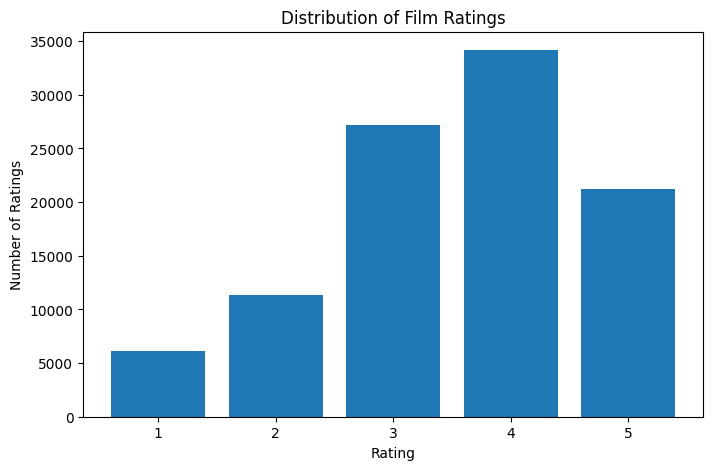

In [38]:
import matplotlib.pyplot as plt

rating_counts = ratings['rating'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(rating_counts.index, rating_counts.values)

plt.xlabel('Rating')
plt.ylabel('Number of Ratings')
plt.title('Distribution of Film Ratings')
plt.xticks([1, 2, 3, 4, 5])

plt.show()

Most films are rated 3 or 4.  This is expected. I feel that people don't rate films as a 5 unless they feel they are truly exceptional and they don't rate them as a 1 or 2 unless they really hated them or didn't finish watching.

I'd also like to see the percentages on this chart.

In [41]:
rating_summary = ratings['rating'].value_counts().sort_index()

rating_summary = pd.DataFrame({
    'Count': rating_summary,
    'Percentage': (rating_summary / len(ratings) * 100).round(2)
})

rating_summary

,Count,Percentage
rating,,
1,6110,6.11
2,11370,11.37
3,27145,27.15
4,34174,34.17
5,21201,21.20


So, which films were most watched and most liked?

First - the most watched films:

In [42]:
top_25_most_rated = (
    df.groupby('film_title')
      .agg(
          number_of_ratings=('rating', 'count'),
          average_rating=('rating', 'mean')
      )
      .sort_values('number_of_ratings', ascending=False)
      .head(25)
)

top_25_most_rated

,number_of_ratings,average_rating
film_title,,
Star Wars (1977),583,4.358491
Contact (1997),509,3.803536
Fargo (1996),508,4.155512
Return of the Jedi (1983),507,4.007890
Liar Liar (1997),485,3.156701
"English Patient, The (1996)",481,3.656965
Scream (1996),478,3.441423
Toy Story (1995),452,3.878319
Air Force One (1997),431,3.631090


I would also like to see the data sorted by average rating:

In [46]:
top_25_most_rated = (
    df.groupby('film_title')
      .agg(
          number_of_ratings=('rating', 'count'),
          average_rating=('rating', 'mean')
      )
      .sort_values('average_rating', ascending=False)
      .head(25)
)

top_25_most_rated

,number_of_ratings,average_rating
film_title,,
Aiqing wansui (1994),1,5.000000
Entertaining Angels: The Dorothy Day Story (1996),1,5.000000
Santa with Muscles (1996),2,5.000000
Prefontaine (1997),3,5.000000
They Made Me a Criminal (1939),1,5.000000
"Saint of Fort Washington, The (1993)",2,5.000000
"Great Day in Harlem, A (1994)",1,5.000000
Star Kid (1997),3,5.000000
Marlene Dietrich: Shadow and Light (1996),1,5.000000


The above data is not a good representation as it shows films with 100% top ratings at the top - but these often only have one rating.  For more meaningful information, I want to see the films that had the most ratings in order of how highly they were rated on average.

Looking at films with the highest ratings, I've decided to only look at the films with greater than 100 ratings overall initially.

In [43]:
film_stats = (
    df.groupby('film_title')
      .agg(
          number_of_ratings=('rating', 'count'),
          average_rating=('rating', 'mean')
      )
)

top_25_highest_rated = (
    film_stats[film_stats['number_of_ratings'] >= 100]
      .sort_values('average_rating', ascending=False)
      .head(25)
)

top_25_highest_rated

,number_of_ratings,average_rating
film_title,,
"Close Shave, A (1995)",112,4.491071
Schindler's List (1993),298,4.466443
"Wrong Trousers, The (1993)",118,4.466102
Casablanca (1942),243,4.456790
"Shawshank Redemption, The (1994)",283,4.445230
Rear Window (1954),209,4.387560
"Usual Suspects, The (1995)",267,4.385768
Star Wars (1977),583,4.358491
12 Angry Men (1957),125,4.344000


As the lowest of the most watched films had 331 ratings, I'm also going to look at the the highest rated films with 331 or greater reviews.

In [47]:
film_stats = (
    df.groupby('film_title')
      .agg(
          number_of_ratings=('rating', 'count'),
          average_rating=('rating', 'mean')
      )
)

top_25_highest_rated = (
    film_stats[film_stats['number_of_ratings'] >= 331]
      .sort_values('average_rating', ascending=False)
      .head(25)
)

top_25_highest_rated

,number_of_ratings,average_rating
film_title,,
Star Wars (1977),583,4.358491
"Silence of the Lambs, The (1991)",390,4.289744
"Godfather, The (1972)",413,4.283293
Raiders of the Lost Ark (1981),420,4.252381
Titanic (1997),350,4.245714
"Empire Strikes Back, The (1980)",367,4.204360
Fargo (1996),508,4.155512
Pulp Fiction (1994),394,4.060914
"Fugitive, The (1993)",336,4.044643


I'd like to see which users didn't rate many films.  Did they only watch their favourite films and rate them as a 5?  Or did they only watch one film, hate it and then not watch any more?  I have checked (via Google) and it seems that an individual user can only rate any film once - so this tells me that we don't have any users watching and rating the same film multiple times.

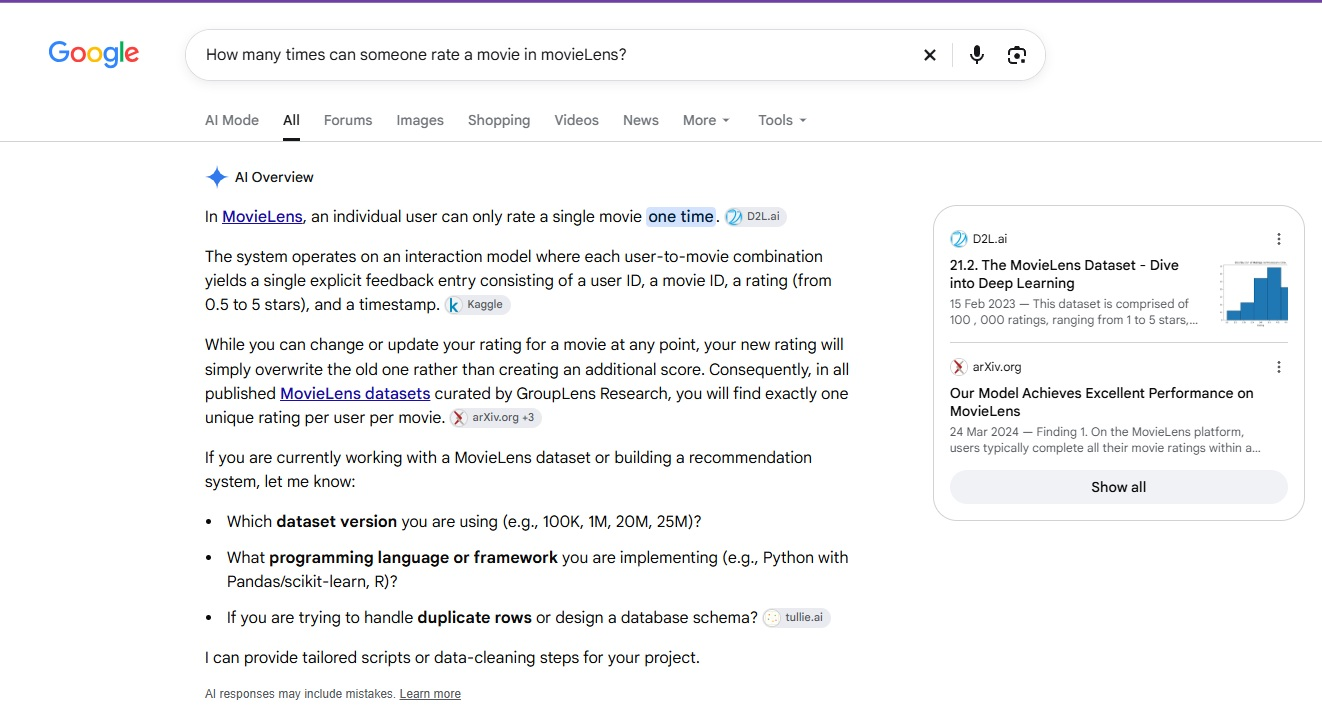

In [48]:
user_activity = (
    ratings.groupby('user_id')
           .size()
           .reset_index(name='number_of_ratings')
)

user_activity.head()

,user_id,number_of_ratings
0,1,272
1,2,62
2,3,54
3,4,24
4,5,175


In [49]:
lowest_activity_users = (
    user_activity
    .sort_values('number_of_ratings', ascending=True)
    .head(25)
)

lowest_activity_users

,user_id,number_of_ratings
18,19,20
894,895,20
887,888,20
865,866,20
872,873,20
823,824,20
35,36,20
33,34,20
811,812,20
739,740,20


The lowest number of films rated in any case was 20, so users were watching and rating multiple films.  I've used the describe feature below to see the basic user activity statistics.  At least one person has watched and rated 737 films!

In [50]:
user_activity['number_of_ratings'].describe()

,number_of_ratings
count,943.000000
mean,106.044539
std,100.931743
min,20.000000
25%,33.000000
50%,65.000000
75%,148.000000
max,737.000000


How does the above information look in a chart?

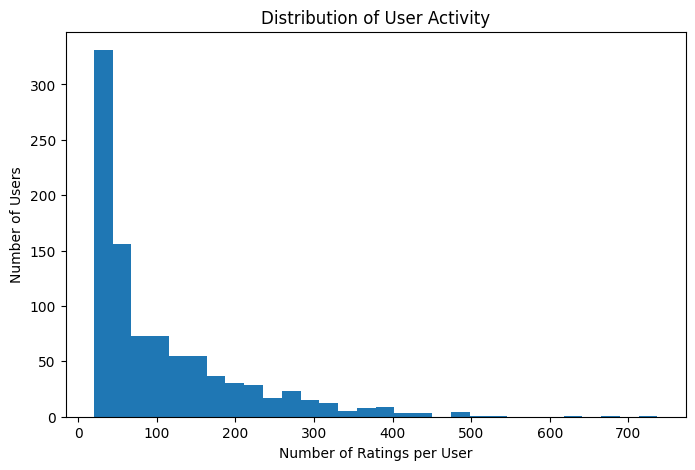

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(user_activity['number_of_ratings'], bins=30)

plt.xlabel('Number of Ratings per User')
plt.ylabel('Number of Users')
plt.title('Distribution of User Activity')

plt.show()

Most users are watching/rating under 200 films.  Let's categorise them into Low, Medium and High activity.

In [52]:
user_activity['activity_group'] = pd.qcut(
    user_activity['number_of_ratings'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

user_activity.groupby('activity_group', observed=True)['number_of_ratings'].agg(
    ['count', 'min', 'mean', 'max']
)

,count,min,mean,max
activity_group,,,,
Low,321,20,28.205607,42
Medium,308,43,70.590909,114
High,314,115,220.394904,737


In [53]:
low_users = user_activity[
    user_activity['activity_group'] == 'Low'
]['user_id']

In [57]:
low_user_films = (
    ratings[ratings['user_id'].isin(low_users)]
    .groupby('user_id')['film_id']
    .nunique()
    .reset_index(name='different_films_rated')
     .sort_values('different_films_rated', ascending=True)
)

low_user_films

,user_id,different_films_rated
30,93,20
275,809,20
301,873,20
300,866,20
245,740,20
...,...,...
194,611,42
73,204,42
57,162,42
234,722,42


I want to analyse the low users - they are our greatest group.  How many films did they watch?

In [56]:
low_user_films['different_films_rated'].describe()

,different_films_rated
count,321.000000
mean,28.205607
std,6.519785
min,20.000000
25%,23.000000
50%,27.000000
75%,33.000000
max,42.000000


We already knew that the lowest number was 20.  The greatest number is 42, so we have a high percentage of users who watched 42 or fewer films.

How many films did they watch between them?

In [58]:
ratings[
    ratings['user_id'].isin(low_users)
]['film_id'].nunique()

895